### Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

## Loading dataset

In [2]:
# removing semicolons separator instead of commas
df =pd.read_csv(r"C:\Users\PC\OneDrive\Desktop\bank.csv", sep=";")
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


## Dataset overview

In [3]:
df.head(5) # viewing the first 5 rows

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [4]:
df.shape    # dataset size

(4521, 17)

In [5]:
df.info()    # dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [6]:
df.describe() # summary statistics

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [7]:
df.isna().sum()  # checking for the missing values

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
df.duplicated().sum()    # checking for duplicate values

np.int64(0)

## Answering business questions

### 1. Which customer age, show the highest subscription "y"?

In [9]:
age_yes = df[(df['y']=='yes')&df.age]

In [10]:
age_yes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
38,33,management,married,secondary,no,3935,yes,no,cellular,6,may,765,1,342,2,failure,yes
49,61,admin.,married,unknown,no,4629,yes,no,cellular,27,jan,181,1,92,1,success,yes
50,45,blue-collar,divorced,primary,no,844,no,no,unknown,5,jun,1018,3,-1,0,unknown,yes
70,37,management,married,tertiary,no,0,no,no,cellular,16,jul,268,2,182,3,success,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,41,entrepreneur,married,primary,no,39,yes,no,cellular,21,nov,549,2,-1,0,unknown,yes
4407,45,admin.,divorced,secondary,no,59,yes,no,cellular,24,jul,873,8,-1,0,unknown,yes
4423,45,management,single,tertiary,no,2048,yes,no,cellular,18,oct,310,1,804,1,failure,yes
4447,49,blue-collar,single,primary,no,2146,yes,no,cellular,7,may,1516,2,353,2,other,yes


In [11]:
# visualizing customer age vs subscription 
fig = px.histogram(
    age_yes, 
    x="age",
   text_auto=True,
    color="y", 
   height=500,
   barmode="overlay", # Overlaps bars instead of stacking them
    opacity=0.7, 
    title="visualizing Age with Y", template = "plotly_dark",
    labels={"age": "Age", "y": "Y"}
)
fig.show()

### 2. Which customer job, show the highest subscription "y"?

In [12]:
job_yes = df[(df['y']=='yes')&df.job]

In [13]:
job_yes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,26,technician,single,secondary,no,668,yes,no,unknown,28,may,576,3,-1,0,unknown,yes
4503,60,self-employed,married,primary,no,362,no,yes,cellular,29,jul,816,6,-1,0,unknown,yes
4504,42,blue-collar,single,secondary,no,1080,yes,yes,cellular,13,may,951,3,370,4,failure,yes
4505,32,admin.,single,secondary,no,620,yes,no,unknown,26,may,1234,3,-1,0,unknown,yes


In [14]:
# visualizing customer job vs subscription "y"

fig = px.histogram(
    job_yes, 
    x="job", 
    color="y", 
    height=700,
    text_auto=True,
    opacity=0.7, 
    title="JOB in reletion with Y", template = "plotly_dark",
    labels={"age": "Age", "y": "Y"}
)
fig.show()

### 3. Which customer marital, show the highest subscription "y"?

In [15]:
marital_yes = df[(df['y']=='yes')&df.marital]

In [16]:
marital_yes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,26,technician,single,secondary,no,668,yes,no,unknown,28,may,576,3,-1,0,unknown,yes
4503,60,self-employed,married,primary,no,362,no,yes,cellular,29,jul,816,6,-1,0,unknown,yes
4504,42,blue-collar,single,secondary,no,1080,yes,yes,cellular,13,may,951,3,370,4,failure,yes
4505,32,admin.,single,secondary,no,620,yes,no,unknown,26,may,1234,3,-1,0,unknown,yes


In [17]:
# visualizing customer marital status vs subscription "y"

fig = px.histogram(
    marital_yes, 
    x="marital", 
    color="y", 
    height=500,
    text_auto=True,
    opacity=0.7, 
    title="view of marital status by Y", template = "plotly_dark",
    labels={"age": "Age", "y": "Y"}
)
fig.show()

### 4. Which customer education, show the highest subscription "y"?

In [18]:
education_yes = df[(df['y']=='yes')&df.education]

In [19]:
education_yes

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
13,20,student,single,secondary,no,502,no,no,cellular,30,apr,261,1,-1,0,unknown,yes
30,68,retired,divorced,secondary,no,4189,no,no,telephone,14,jul,897,2,-1,0,unknown,yes
33,32,management,single,tertiary,no,2536,yes,no,cellular,26,aug,958,6,-1,0,unknown,yes
34,49,technician,married,tertiary,no,1235,no,no,cellular,13,aug,354,3,-1,0,unknown,yes
36,78,retired,divorced,primary,no,229,no,no,telephone,22,oct,97,1,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4494,26,technician,single,secondary,no,668,yes,no,unknown,28,may,576,3,-1,0,unknown,yes
4503,60,self-employed,married,primary,no,362,no,yes,cellular,29,jul,816,6,-1,0,unknown,yes
4504,42,blue-collar,single,secondary,no,1080,yes,yes,cellular,13,may,951,3,370,4,failure,yes
4505,32,admin.,single,secondary,no,620,yes,no,unknown,26,may,1234,3,-1,0,unknown,yes


In [20]:
# visualizing customer marital status vs subscription "y"

fig = px.histogram(
    education_yes, 
    x="education", 
    color="y", 
    height=700,
    text_auto=True,
    opacity=0.7, 
    title="view education by Y", template = "plotly_dark",
    labels={"age": "Age", "y": "Y"}
)
fig.show()

### 5. How do financial attributes—such as average yearly balance, housing loans, or personal loans—correlate with a client's willingness to open a term deposit?

In [21]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


##### a. Correlating a Numerical Attribute (Average Yearly Balance)

In [22]:
# 1. Calculate the average balance for each 'y' group
bal_mean = df.groupby('y')['balance'].mean()
bal_mean

y
no     1403.211750
yes    1571.955854
Name: balance, dtype: float64

In [23]:
# Step 2: Calculate percentage of each group mean relative to the total of means
bal_perc = (bal_mean/ bal_mean.sum()).mul(100).round(0).astype(int)

bal_perc

y
no     47
yes    53
Name: balance, dtype: int64

In [24]:
# 2. Create an interactive box plot to see the spread
fig = px.bar(bal_perc, height=500,
             title='Average Yearly Balance Distribution by Target (y)',
             template = "plotly_dark", text_auto=True, 
             )
fig.show()

##### b. Correlating Categorical Attributes (Housing or Personal Loans)

In [25]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [26]:
# Get exact percentages with a cross-tabulation table "housing"
print(pd.crosstab(df['housing'], df['y'], normalize='index').mul(100).round(0).astype(int)) 

# Create a grouped bar chart
fig = px.histogram(df, x='housing', color='y', barmode='group', text_auto=True, template = "plotly_dark", height=500,
                   title='How Housing Loans Affect the Target Variable (y)')
fig.show()

y        no  yes
housing         
no       85   15
yes      91    9


In [27]:
# Get exact percentages with a cross-tabulation table "loan"
print(pd.crosstab(df['loan'], df['y'], normalize='index') .mul(100).round(0).astype(int).reset_index()) 

# Create a grouped bar chart
fig = px.histogram(df, x='loan', color='y', barmode='group', text_auto=True,template = "plotly_dark", height=500,
                   title='How personal Loan Affect the Target Variable (y)')
fig.show()

y loan  no  yes
0   no  88   12
1  yes  94    6


### 6. Do customers with existing credit defaults show significantly lower subscription rates?

In [28]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [29]:
# We group by 'default' and find the percentage of 'yes' in 'subscribed'
df_rates = (
    df.groupby('default')['y']
    .value_counts(normalize=True)  # Get proportions (0.0 to 1.0)
    .rename('percentage')
    .reset_index()
)

# Multiply by 100 to get clean percentage numbers
df_rates['percentage'] = df_rates['percentage'] * 100

# Filter to only look at the 'yes' subscription rates
df_subscription_rate = df_rates[df_rates['y'] == 'yes']

# Create the bar chart using Plotly Express
fig = px.bar(
    df_subscription_rate, 
    x='default', 
    y='percentage',
    text='percentage',
    title='Subscription Rate by Credit Default Status',
    labels={'default': 'Has Credit Default?', 'percentage': 'Subscription Rate (%)'},
    color='default',template = "plotly_dark", height=500,
    color_discrete_map={'no': '#2ecc71', 'yes': '#e74c3c'} # Green for no default, Red for default
)

# Clean up the chart look
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')

# Display the chart
fig.show()

### 7. What percentage of customers actually subscribed (yes vs. no), and how severe is the class imbalance?


In [30]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [31]:
# Calculate percentages and counts
# value_counts(normalize=True) gives the proportion; multiplying by 100 gives the %
imbalance_df = df['y'].value_counts().reset_index()
imbalance_df.columns = ['y', 'Count']
imbalance_df['Percentage'] = (df['y'].value_counts(normalize=True).values * 100).round(0)

# Display the summary table
imbalance_df

,y,Count,Percentage
0,no,4000,88.0
1,yes,521,12.0


In [32]:
# Visualize using Plotly Express
fig = px.bar(
    imbalance_df, 
    x='y', 
    y='Count', 
    text='Percentage',
    title='Customer Subscription Class Imbalance',
    labels={'Count': 'Number of Customers', 'Subscribed': 'Subscribed (Yes/No)'},
    color='y', template = "plotly_dark", height=500,
    color_discrete_map={'yes': '#2ECC71', 'no': '#E74C3C'} # Green for yes, Red for no
)

# Format the percentage text on top of the bars
fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.show()

### 8. Which communication channel works best? Does cellular contact yield higher conversion rates than telephone or unknown methods?

In [33]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [34]:
# Calculate absolute counts and conversion percentages

grouped = df.groupby(['contact', 'y']).size().reset_index(name='count').round(0)
grouped['percentage'] = grouped.groupby('contact')['count'].transform(lambda x: (x / x.sum()) * 100).round(0)
grouped

,contact,y,count,percentage
0,cellular,no,2480,86.0
1,cellular,yes,416,14.0
2,telephone,no,257,85.0
3,telephone,yes,44,15.0
4,unknown,no,1263,95.0
5,unknown,yes,61,5.0


In [35]:
# Generate a 100% stacked bar chart to directly compare success rates
fig = px.bar(
    grouped, 
    x='contact', 
    y='percentage', 
    color='y',template = "plotly_dark", height=500,
    text=grouped['percentage'].apply(lambda x: f'{x:.1f}%'),
    title='Term Deposit Subscription Success Rate: Cellular vs. Telephone',
    labels={'contact': 'Communication Channel', 'percentage': 'Percentage of Total Calls (%)', 'y': 'Subscribed (y)'},
    color_discrete_map={'yes': '#2ecc71', 'no': '#e74c3c'},
    barmode='stack'
)

fig.show()


### 9. Which months or days of the month has the highest subscription rates?

In [36]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no


In [37]:
# Convert target variable 'y' to binary (1 for yes, 0 for no) to easily calculate rates
df['subscribed'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# Define month chronological order for clean sorting
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'out', 'nov', 'dec']

# Monthly Subscription Rates
monthly_data = df.groupby('month').agg(
    total_calls=('subscribed', 'count'),
    subscription_rate=('subscribed', 'mean')
).reindex(month_order).reset_index()

# Convert rate to percentage
monthly_data['subscription_rate'] *= 100

# Plot Monthly Subscription Rates
fig_month = px.bar(
    monthly_data, 
    x='month', 
    y='subscription_rate',
    text=monthly_data['subscription_rate'].apply(lambda x: f"{x:.1f}%"),
    title='<b>Term Deposit Subscription Rate by Month</b>',
    labels={'subscription_rate': 'Subscription Rate (%)', 'month': 'Month'},
    color='subscription_rate',
    color_continuous_scale='Viridis'
)
fig_month.update_layout(xaxis_title="Month", yaxis_title="Success Rate (%)", template="plotly_dark")
fig_month.show()


# Day of the Month Subscription Rates
daily_data = df.groupby('day').agg(
    total_calls=('subscribed', 'count'),
    subscription_rate=('subscribed', 'mean')
).sort_index().reset_index()

daily_data['subscription_rate'] *= 100

# Plot Daily Subscription Rates
fig_day = px.line(
    daily_data, 
    x='day', 
    y='subscription_rate',
    markers=True,
    title='<b>Term Deposit Subscription Rate by Day of the Month</b>',
    labels={'subscription_rate': 'Subscription Rate (%)', 'day': 'Days'},
)
fig_day.update_layout(
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    yaxis_title="Success Rate (%)", 
    template="plotly_dark"
)
fig_day.show()

 ### 10. How does the number of contacts (campaign) during the current drive affect client fatigue and refusal rates?

In [38]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0


In [39]:
df['campaign'].unique()

array([ 1,  4,  2,  5,  3,  6, 18, 10,  9,  7, 12, 14, 13, 24, 11,  8, 29,
       32, 16, 22, 15, 30, 25, 21, 17, 19, 23, 20, 50, 28, 31, 44])

In [40]:
df['campaign'].nunique()

32

In [41]:
# The target variable is usually 'y' (yes/no). Let's convert it to a numeric refusal indicator.
# Refusal = 1 if the client did NOT subscribe ('no'), and 0 if they subscribed ('yes')
df['is_refusal'] = df['y'].apply(lambda x: 1 if x == 'no' else 0)

# Aggregate metrics by the number of contacts ('campaign')
campaign_analysis = df.groupby('campaign').agg(
    total_contacts=('y', 'count'),
    total_refusals=('is_refusal', 'sum')
).reset_index()

# Calculate the Refusal Rate (%) and Conversion Rate (%)
campaign_analysis['refusal_rate'] = (campaign_analysis['total_refusals'] / campaign_analysis['total_contacts']) * 100
campaign_analysis['conversion_rate'] = 100 - campaign_analysis['refusal_rate']

# Filter out extreme outliers with tiny sample sizes (e.g., campaigns with > 15 contacts)
# to keep the visualization clean and statistically meaningful.
filtered_analysis = campaign_analysis[campaign_analysis['campaign'] <= 15]

# 3. Create a dual visualization with Plotly Express
# Line chart to show how Refusal and Conversion Rates trend alongside contact frequency
fig = px.line(
    filtered_analysis, 
    x='campaign', 
    y=['refusal_rate', 'conversion_rate'],
    labels={'campaign': 'Number of Contacts (Current Campaign)', 'value': 'Percentage (%)', 'variable': 'Metric'},
    title='Client Fatigue Analysis: Contact Frequency vs. Response Rates',
    markers=True,template = "plotly_dark", height=500,
    category_orders={"variable": ["refusal_rate", "conversion_rate"]}
)

# Customize line styling and update trace names for readability
fig.update_traces(patch={"name": "Refusal Rate (%)"}, selector={"name": "refusal_rate"})
fig.update_traces(patch={"name": "Conversion Rate (%)"}, selector={"name": "conversion_rate"})

# Display the interactive chart
fig.show()

### How does the duration of a phone call correlate with the term deposit subscription rate (y)?

In [42]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed,is_refusal
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0,1
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0,1


In [43]:
# Assuming df is your bank marketing DataFrame
mean_duration = df.groupby('y')['duration'].mean()
print(mean_duration)

# Check correlation coefficient directly
df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})
correlation = df['duration'].corr(df['y_numeric'])
print(f'Correlation: {correlation:.2f}')

y
no     226.347500
yes    552.742802
Name: duration, dtype: float64
Correlation: 0.40


In [44]:
fig = px.box(
    df,
    x='y',
    y='duration',
    title='Call Duration by Term Deposit Subscription',
    labels={'y': 'Subscribed (y)', 'duration': 'Call Duration (seconds)'},
    color='y', template = "plotly_dark", height=500,
)
fig.show()

 ### Does the recency of communication impact a customer's willingness to subscribe?

In [45]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,subscribed,is_refusal,y_numeric
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no,0,1,0
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0,1,0


In [46]:
# Separate customers into 'Never Contacted' vs 'Previously Contacted'
df['contact'] = df['pdays'].apply(lambda x: 'Never Contacted' if x == 999 else 'Previously Contacted')

# Create recency segments for those who *were* previously contacted
def segment_recency(days):
    if days == 999:
        return 'Never Contacted'
    elif days <= 5:
        return '0-5 Days (Very Recent)'
    elif days <= 10:
        return '6-10 Days (Recent)'
    else:
        return '11+ Days (Distant)'

df['recency_segment'] = df['pdays'].apply(segment_recency)

# Group by the segments and calculate conversion percentages
conversion_df = df.groupby('recency_segment')['y'].value_counts(normalize=True).unstack(fill_value=0) * 100
conversion_df = conversion_df.reset_index()

# Ensure chronological ordering for the plot
category_order = ['0-5 Days (Very Recent)', '6-10 Days (Recent)', '11+ Days (Distant)', 'Never Contacted']
conversion_df['recency_segment'] = pd.Categorical(conversion_df['recency_segment'], categories=category_order, ordered=True)
conversion_df = conversion_df.sort_values('recency_segment')

# Visualization using Plotly Express 

fig = px.bar(
    conversion_df, 
    x='recency_segment', 
    y='yes',
    title="Subscription Rate by Recency of Last Marketing Contact",
    labels={'recency_segment': 'Recency of Last Contact', 'yes': 'Subscription Success Rate'},
    text_auto='.1f',
    color='recency_segment',
    color_discrete_sequence=px.colors.sequential.Viridis
)

fig.update_layout(
    showlegend=False,
    template = "plotly_dark", height=500,
)

# Display the plot
fig.show()

 ### Does higher historical familiarity with the bank increase conversion, or does it cause customer fatigue?

In [47]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,subscribed,is_refusal,y_numeric,recency_segment
0,30,unemployed,married,primary,no,1787,no,no,Previously Contacted,19,...,79,1,-1,0,unknown,no,0,1,0,0-5 Days (Very Recent)
1,33,services,married,secondary,no,4789,yes,yes,Previously Contacted,11,...,220,1,339,4,failure,no,0,1,0,11+ Days (Distant)


In [48]:
# Standardize target variable to numeric for easy rate calculation
df['converted'] = df['y'].apply(lambda x: 1 if x == 'yes' else 0)

# 2. Cap 'previous' contacts to aggregate long-tail outliers (e.g., 5+)
df['historical_contacts'] = df['previous'].apply(lambda x: str(x) if x < 5 else '5+')

# 3. Calculate conversion rates by historical familiarity
familiarity_df = df.groupby('historical_contacts')['converted'].agg(['count', 'mean']).reset_index()
familiarity_df['conversion_rate (%)'] = familiarity_df['mean'] * 100

# 4. Plot Trust/Familiarity Curve
fig_trust = px.bar(
    familiarity_df, 
    x='historical_contacts', 
    y='conversion_rate (%)',
    text='conversion_rate (%)',
    title='<b>Familiarity Effect:</b> Conversion Rate by Historical Touchpoints',
    labels={'historical_contacts': 'Number of Past Contacts (Prior Campaigns)', 'conversion_rate (%)': 'Conversion Rate (%)'},
    template = "plotly_dark", height=500,
)
fig_trust.update_traces(texttemplate='%{text:.1f}%', textposition='outside', marker_color='rgb(49, 130, 189)')
fig_trust.show()

In [49]:
# 1. Cap current campaign frequency to capture fatigue dropoff (e.g., up to 10 calls)
df['current_campaign_calls'] = df['campaign'].apply(lambda x: str(x) if x <= 9 else '10+')

# 2. Calculate conversion rates by ongoing campaign pressure
fatigue_df = df.groupby('current_campaign_calls')['converted'].agg(['count', 'mean']).reset_index()
fatigue_df['conversion_rate (%)'] = fatigue_df['mean'] * 100

# Sort accurately by numerical context
fatigue_df['sort_idx'] = fatigue_df['current_campaign_calls'].apply(lambda x: int(x) if x != '10+' else 10)
fatigue_df = fatigue_df.sort_values('sort_idx')

# 3. Plot Fatigue Curve
fig_fatigue = px.line(
    fatigue_df, 
    x='current_campaign_calls', 
    y='conversion_rate (%)',
    markers=True,
    title='<b>Fatigue Effect:</b> Conversion Decay by Current Campaign Call Volume',
    labels={'current_campaign_calls': 'Number of Calls in Current Campaign', 'conversion_rate (%)': 'Conversion Rate (%)'},
    template='plotly_dark', height=500,
)
fig_fatigue.update_traces(line_color='rgb(214, 39, 40)', marker=dict(size=8))
fig_fatigue.show()

### How predictive is past customer behavior on current campaign success?

In [50]:
df.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,...,previous,poutcome,y,subscribed,is_refusal,y_numeric,recency_segment,converted,historical_contacts,current_campaign_calls
0,30,unemployed,married,primary,no,1787,no,no,Previously Contacted,19,...,0,unknown,no,0,1,0,0-5 Days (Very Recent),0,0,1
1,33,services,married,secondary,no,4789,yes,yes,Previously Contacted,11,...,4,failure,no,0,1,0,11+ Days (Distant),0,4,1


In [51]:
# Calculate conversion rate based on previous campaign outcome
poutcome_analysis = (
    df.groupby('poutcome')['y']
    .value_counts(normalize=True).mul(100).round(0).astype(int)
    .unstack()
    .fillna(0)
)
print(poutcome_analysis)

y         no  yes
poutcome         
failure   87   13
other     81   19
success   36   64
unknown   91    9


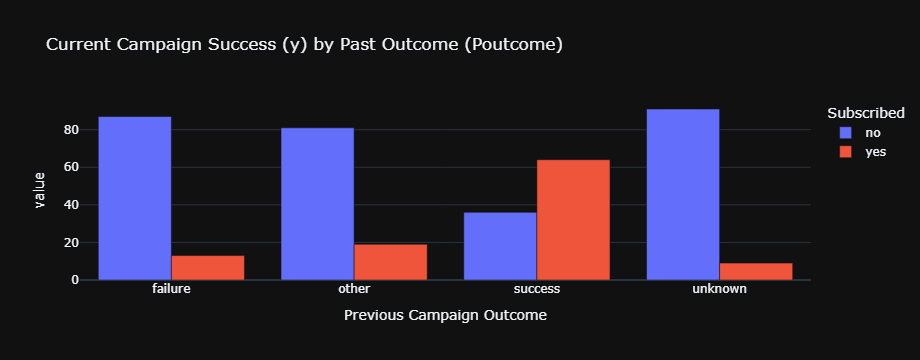

In [52]:
# Create an interactive grouped bar chart
fig = px.bar(
    poutcome_analysis, 
    color='y',
    barmode='group',
    title='Current Campaign Success (y) by Past Outcome (Poutcome)',
    labels={
        'poutcome': 'Previous Campaign Outcome',
        'count': 'Customer Count',
        'y': 'Subscribed',
    },
)

fig.update_layout(template='plotly_dark')
fig.show()